In [1]:
from functools import reduce
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.categories import subcat_to_cat

import pickle

In [2]:
# preds_path_ls = [
#     ('raw 0 shot',   r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\Raw_0sh.bin'),
#     ('raw 5 shot',   r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\Raw_5sh.bin'),
#     ('LoRA 0 shot',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\LoRA-cfg13_0sh.bin'),
#     ('LoRA 5 shot',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\LoRA-cfg13_5sh.bin'),
#     ('GSOFT 0 shot', r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\GSOFT-cfg0_0sh.bin'),
#     ('GSOFT 5 shot', r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\GSOFT-cfg0_5sh.bin'),
# ]

# preds_path_ls = [
#     ('raw 0 shot',   r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\Raw_0sh.bin'),
#     ('raw 5 shot',   r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\Raw_5sh.bin'),
#     ('LoRA 0 shot',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\LoRA-cfg17_0sh.bin'),
#     ('LoRA 5 shot',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\LoRA-cfg17_5sh.bin'),
#     ('LoRA-code 0 shot',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\LoRA-cfg18-code-ift-MMLU_0sh.bin'),
#     ('LoRA-code 5 shot',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\LoRA-cfg18-code-ift-MMLU_5sh.bin'),
#     ('GSOFT-code 0 shot',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\GSOFT-cfg3-code-ift-MMLU_0sh.bin'),
#     ('GSOFT-code 5 shot',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\GSOFT-cfg3-code-ift-MMLU_5sh.bin'),
#     # ('LoRA-CR 0 shot',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\LoRA-cfg18-OOD-MMLU_0sh.bin'),
#     # ('LoRA-CR 5 shot',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\LoRA-cfg18-OOD-MMLU_5sh.bin'),
#     # ('DoRA-CR 0 shot',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\DoRA-cfg18-OOD-MMLU_0sh.bin'),
#     # ('DoRA-CR 5 shot',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\DoRA-cfg18-OOD-MMLU_5sh.bin'),
#     # ('GSOFT-CR 0 shot',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\GSOFT-cfg3-OOD-MMLU_0sh.bin'),
#     # ('GSOFT-CR 5 shot',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\GSOFT-cfg3-OOD-MMLU_5sh.bin'),
#     # ('VeRA-CR 0 shot',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\VeRA-cfg1-OOD-MMLU_0sh.bin'),
#     # ('VeRA-CR 5 shot',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\VeRA-cfg1-OOD-MMLU_5sh.bin'),
# ]

LoRA_cfg = 3
GSOFT_cfg = 13

preds_path_ls = [
    ('Raw 1b',   r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\Raw_1b_5sh.bin'),
    ('LoRA_1b-CR',   rf'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\LoRA_1b-cfg{LoRA_cfg}-CR_5sh.bin'),
    ('GSOFT_1b-CR',   rf'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\GSOFT_1b-cfg{GSOFT_cfg}-CR_5sh.bin'),
]

max_step = 8_000
for st in range(2_000, max_step+1, 2_000):
    preds_path_ls.append(
        (f'LoRA_1b-code st-{st}',   rf'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\LoRA_1b-cfg{LoRA_cfg}-st{st}-MMLU_5sh.bin')
    )

for st in range(2_000, max_step+1, 2_000):
    preds_path_ls.append(
        (f'GSOFT_1b-code st-{st}',   rf'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\GSOFT_1b-cfg{GSOFT_cfg}-st{st}-MMLU_5sh.bin')
    )

In [3]:
preds_dfs = {}

for run_name, preds_path in preds_path_ls:
    with open(preds_path, 'rb') as f:
        preds_dfs[run_name] = pickle.load(file=f)

        print(f"{run_name:16}: {preds_dfs[run_name].shape=}")

Raw 1b          : preds_dfs[run_name].shape=(14042, 7)
LoRA_1b-CR      : preds_dfs[run_name].shape=(14042, 7)
GSOFT_1b-CR     : preds_dfs[run_name].shape=(14042, 7)
LoRA_1b-code st-2000: preds_dfs[run_name].shape=(14042, 7)
LoRA_1b-code st-4000: preds_dfs[run_name].shape=(14042, 7)
LoRA_1b-code st-6000: preds_dfs[run_name].shape=(14042, 7)
LoRA_1b-code st-8000: preds_dfs[run_name].shape=(14042, 7)
GSOFT_1b-code st-2000: preds_dfs[run_name].shape=(14042, 7)
GSOFT_1b-code st-4000: preds_dfs[run_name].shape=(14042, 7)
GSOFT_1b-code st-6000: preds_dfs[run_name].shape=(14042, 7)
GSOFT_1b-code st-8000: preds_dfs[run_name].shape=(14042, 7)


In [4]:
idx = 6

print(preds_dfs['Raw 1b']['text'][idx])
print(preds_dfs['Raw 1b']['model_pred'][idx])

<|begin_of_text|><|start_header_id|>system<|end_header_id|>

The following are multiple choice questions (with answers) about abstract_algebra. Output 'A', 'B', 'C', or 'D'. Full answer not needed.<|eot_id|><|start_header_id|>user<|end_header_id|>

Find all c in Z_3 such that Z_3[x]/(x^2 + c) is a field.
A. 0
B. 1
C. 2
D. 3<|eot_id|><|start_header_id|>assistant<|end_header_id|>

B<|eot_id|><|start_header_id|>user<|end_header_id|>

Statement 1 | If aH is an element of a factor group, then |aH| divides |a|. Statement 2 | If H and K are subgroups of G then HK is a subgroup of G.
A. True, True
B. False, False
C. True, False
D. False, True<|eot_id|><|start_header_id|>assistant<|end_header_id|>

B<|eot_id|><|start_header_id|>user<|end_header_id|>

Statement 1 | Every element of a group generates a cyclic subgroup of the group. Statement 2 | The symmetric group S_10 has 10 elements.
A. True, True
B. False, False
C. True, False
D. False, True<|eot_id|><|start_header_id|>assistant<|end_header_i

In [5]:
# tmp_idxs = preds_dfs['Raw 1b 0 shot']['model_pred'].apply(
#     lambda p: re.match('[ABCD]', p['generated_text']) is not None
# )

# preds_dfs['Raw 1b 0 shot']['model_pred'][~tmp_idxs].shape

In [6]:
def get_category(subject):
    return subcat_to_cat[subject]

# OOD_part = re.compile('The correct answer is [ABCD]')
# OOD_part_len = len('The correct answer is ')

OOD_parts = [
    (re.compile('The correct answer is [ABCD]'), len('The correct answer is ')),
    (re.compile('The answer is [ABCD]'), len('The answer is ')),
    (re.compile('The solution is [ABCD]'), len('The solution is ')),
]

def get_pred(p):
    for OOD_part, OOD_part_len in OOD_parts:
        if OOD_part.search(p):
            return p[OOD_part_len]
    
    return p[0]

def processor(row: pd.DataFrame):
    generated_text = row['model_pred']['generated_text']
    generated_text = generated_text.strip()
    

    # generated_text	subject	pred	true	corr	category
    category = get_category(row['subject'])
    pred = get_pred(generated_text)
    true = chr(ord('A') + row['answer'])
    corr = int(pred == true)

    return {
        'generated_text': generated_text,
        'subject': row['subject'],
        'pred': pred,
        'true': true,
        'corr': corr,
        'category': category
    }

In [7]:
print(*preds_dfs.keys(), sep='\n')

Raw 1b
LoRA_1b-CR
GSOFT_1b-CR
LoRA_1b-code st-2000
LoRA_1b-code st-4000
LoRA_1b-code st-6000
LoRA_1b-code st-8000
GSOFT_1b-code st-2000
GSOFT_1b-code st-4000
GSOFT_1b-code st-6000
GSOFT_1b-code st-8000


In [8]:
for run_name in preds_dfs.keys():
    preds_dfs[run_name] = preds_dfs[run_name].apply(processor, axis=1, result_type='expand')

In [9]:
preds_dfs['Raw 1b'].head()

,generated_text,subject,pred,true,corr,category
0,C,abstract_algebra,C,B,0,STEM
1,C,abstract_algebra,C,C,1,STEM
2,C,abstract_algebra,C,D,0,STEM
3,C,abstract_algebra,C,B,0,STEM
4,To find the product of the given polynomials i...,abstract_algebra,T,B,0,STEM


In [10]:
preds_dfs['LoRA_1b-CR'].head()

,generated_text,subject,pred,true,corr,category
0,The correct answer is B. 4.\n\nTo find the deg...,abstract_algebra,B,B,1,STEM
1,The answer is B. 2.,abstract_algebra,B,C,0,STEM
2,"The correct answer is D. 0,4.",abstract_algebra,D,D,1,STEM
3,B,abstract_algebra,B,B,1,STEM
4,The correct answer is B. 6x^2 + 4x +,abstract_algebra,B,B,1,STEM


In [11]:
acc_by_subjects = pd.DataFrame({
    'subject': list(set.union(
        *map(
            lambda df: set(df['subject']),
            preds_dfs.values()
        )
    ))
})

print(f"Subjects: {acc_by_subjects['subject']}")

for run_name, preds_df in preds_dfs.items():
    acc_df = preds_df[['subject', 'corr']].groupby(['subject'], as_index=False).mean()
    acc_df.rename(columns={'corr': run_name}, inplace=True)

    acc_by_subjects = acc_by_subjects.merge(
        acc_df,
        left_on='subject',
        right_on='subject',
        how='right'
    )

Subjects: 0                              philosophy
1                        professional_law
2                      clinical_knowledge
3                               nutrition
4                  high_school_statistics
5                       computer_security
6                         world_religions
7                        college_medicine
8     high_school_government_and_politics
9                         business_ethics
10                        human_sexuality
11                    high_school_physics
12                           econometrics
13                     conceptual_physics
14                         moral_disputes
15           high_school_computer_science
16                  high_school_chemistry
17               college_computer_science
18                      international_law
19                        college_biology
20                professional_psychology
21                       security_studies
22                professional_accounting
23                      

In [12]:
acc_by_subjects

,subject,Raw 1b,LoRA_1b-CR,GSOFT_1b-CR,LoRA_1b-code st-2000,LoRA_1b-code st-4000,LoRA_1b-code st-6000,LoRA_1b-code st-8000,GSOFT_1b-code st-2000,GSOFT_1b-code st-4000,GSOFT_1b-code st-6000,GSOFT_1b-code st-8000
0,abstract_algebra,0.260000,0.300000,0.310000,0.250000,0.270000,0.210000,0.220000,0.260000,0.270000,0.260000,0.230000
1,anatomy,0.488889,0.422222,0.481481,0.466667,0.451852,0.422222,0.444444,0.555556,0.503704,0.511111,0.488889
2,astronomy,0.526316,0.348684,0.460526,0.434211,0.421053,0.388158,0.401316,0.539474,0.526316,0.486842,0.447368
3,business_ethics,0.500000,0.430000,0.480000,0.460000,0.410000,0.380000,0.340000,0.510000,0.450000,0.420000,0.440000
4,clinical_knowledge,0.486792,0.369811,0.475472,0.407547,0.415094,0.422642,0.415094,0.501887,0.513208,0.513208,0.483019
5,college_biology,0.430556,0.361111,0.409722,0.409722,0.430556,0.423611,0.395833,0.500000,0.423611,0.451389,0.458333
6,college_chemistry,0.270000,0.260000,0.280000,0.300000,0.330000,0.370000,0.370000,0.340000,0.330000,0.330000,0.340000
7,college_computer_science,0.240000,0.240000,0.380000,0.380000,0.390000,0.340000,0.320000,0.340000,0.410000,0.390000,0.410000
8,college_mathematics,0.240000,0.310000,0.270000,0.330000,0.340000,0.350000,0.340000,0.310000,0.350000,0.330000,0.270000
9,college_medicine,0.393064,0.289017,0.341040,0.358382,0.369942,0.393064,0.410405,0.416185,0.462428,0.468208,0.416185


In [13]:
acc_by_categories = pd.DataFrame({
    'category': list(set.union(
        *map(
            lambda df: set(df['category']),
            preds_dfs.values()
        )
    ))
})

for run_name, preds_df in preds_dfs.items():
    acc_df = preds_df[['category', 'corr']].groupby(['category'], as_index=False).mean()
    acc_df.rename(columns={'corr': run_name}, inplace=True)

    acc_by_categories = acc_by_categories.merge(
        acc_df,
        left_on='category',
        right_on='category',
        how='right'
    )

In [14]:
acc_by_categories.loc[:, list(filter(
    lambda s: ('5 shot' not in s),
    acc_by_categories.columns
))]

,category,Raw 1b,LoRA_1b-CR,GSOFT_1b-CR,LoRA_1b-code st-2000,LoRA_1b-code st-4000,LoRA_1b-code st-6000,LoRA_1b-code st-8000,GSOFT_1b-code st-2000,GSOFT_1b-code st-4000,GSOFT_1b-code st-6000,GSOFT_1b-code st-8000
0,STEM,0.358516,0.305169,0.356196,0.335321,0.353877,0.356196,0.349901,0.377071,0.377071,0.374089,0.358516
1,humanities,0.414665,0.330287,0.375133,0.359830,0.362593,0.358767,0.351966,0.401063,0.396387,0.397450,0.365781
2,"other (business, health, misc.)",0.502468,0.402529,0.471006,0.441703,0.445404,0.442320,0.432758,0.502159,0.484269,0.490438,0.480259
3,social sciences,0.488463,0.379266,0.436464,0.441664,0.451414,0.446214,0.441664,0.489113,0.485863,0.476113,0.458239


In [15]:
acc_by_categories.loc[:, list(filter(
    lambda s: ('0 shot' not in s),
    acc_by_categories.columns
))]

,category,Raw 1b,LoRA_1b-CR,GSOFT_1b-CR,LoRA_1b-code st-2000,LoRA_1b-code st-4000,LoRA_1b-code st-6000,LoRA_1b-code st-8000,GSOFT_1b-code st-2000,GSOFT_1b-code st-4000,GSOFT_1b-code st-6000,GSOFT_1b-code st-8000
0,STEM,0.358516,0.305169,0.356196,0.335321,0.353877,0.356196,0.349901,0.377071,0.377071,0.374089,0.358516
1,humanities,0.414665,0.330287,0.375133,0.359830,0.362593,0.358767,0.351966,0.401063,0.396387,0.397450,0.365781
2,"other (business, health, misc.)",0.502468,0.402529,0.471006,0.441703,0.445404,0.442320,0.432758,0.502159,0.484269,0.490438,0.480259
3,social sciences,0.488463,0.379266,0.436464,0.441664,0.451414,0.446214,0.441664,0.489113,0.485863,0.476113,0.458239


In [16]:
total_res = pd.DataFrame(columns=['run_name', 'accuracy', 'correctness'])

for run_name, preds_df in preds_dfs.items():
    total_accuracy = preds_df['corr'].mean()
    total_correctness = (preds_df['pred'].isin(['A', 'B', 'C', 'D'])).mean()

    total_res = pd.concat([
        total_res,
        pd.DataFrame({
            'run_name': [run_name],
            'accuracy': [total_accuracy],
            'correctness': [total_correctness],
        })
    ])

C:\Users\Vladimir\AppData\Local\Temp\ipykernel_26116\1869384032.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  total_res = pd.concat([


In [17]:
total_res

,run_name,accuracy,correctness
0,Raw 1b,0.439040,0.997935
0,LoRA_1b-CR,0.352300,0.972084
0,GSOFT_1b-CR,0.406637,0.999573
0,LoRA_1b-code st-2000,0.391397,0.999217
0,LoRA_1b-code st-4000,0.399302,0.999074
0,LoRA_1b-code st-6000,0.396667,0.997650
0,LoRA_1b-code st-8000,0.389831,0.996510
0,GSOFT_1b-code st-2000,0.438542,0.995941
0,GSOFT_1b-code st-4000,0.432132,0.993377
0,GSOFT_1b-code st-6000,0.431135,0.993163


In [18]:
# preds_dfs['GSOFT_1b-CR'][preds_dfs['GSOFT_1b-CR'].pred != preds_dfs['GSOFT_1b-CR_old'].pred]

Text(0, 0.5, 'MMLU 5sh accuracy')

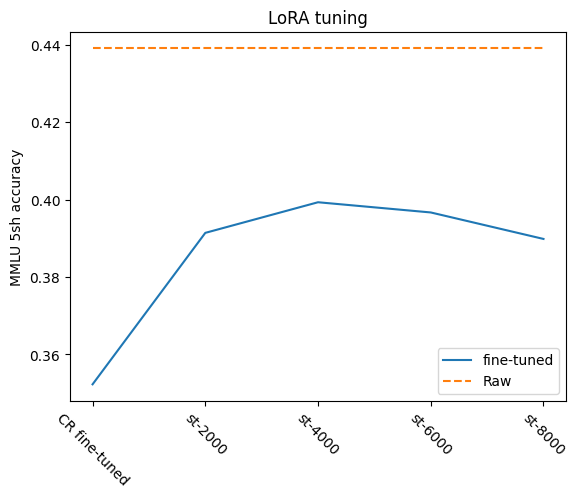

In [19]:
scores = [total_res[total_res['run_name'] == 'LoRA_1b-CR'].accuracy[0]]
scores += [
    total_res[total_res['run_name'] == f'LoRA_1b-code st-{st}'].accuracy[0]
    for st in range(2000, max_step+1,2000)
]

sns.lineplot(
    x=range(0, max_step+1, 2000),
    y=scores,
    label='fine-tuned'
)

sns.lineplot(
    x=[0, max_step],
    y=[total_res[total_res['run_name'] == 'Raw 1b'].accuracy.iloc[-1]] * 2,
    linestyle='--',
    label='Raw'
)

plt.xticks(
    range(0, max_step+1,2000),
    labels=['CR fine-tuned'] + [f'st-{st}' for st in range(2000, max_step+1,2000)],
    rotation=-45
)

plt.title('LoRA tuning')
plt.ylabel('MMLU 5sh accuracy')

Text(0, 0.5, 'MMLU 5sh accuracy')

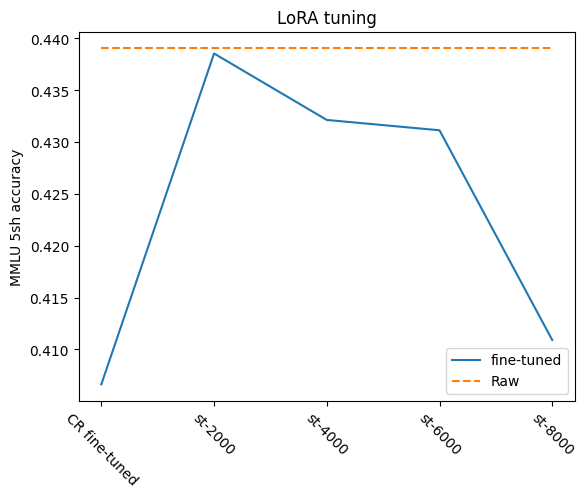

In [20]:
scores = [total_res[total_res['run_name'] == 'GSOFT_1b-CR'].accuracy[0]]
scores += [
    total_res[total_res['run_name'] == f'GSOFT_1b-code st-{st}'].accuracy[0]
    for st in range(2000, max_step+1,2000)
]

sns.lineplot(
    x=range(0, max_step+1, 2000),
    y=scores,
    label='fine-tuned'
)

sns.lineplot(
    x=[0, max_step],
    y=[total_res[total_res['run_name'] == 'Raw 1b'].accuracy.iloc[-1]] * 2,
    linestyle='--',
    label='Raw'
)

plt.xticks(
    range(0, max_step+1,2000),
    labels=['CR fine-tuned'] + [f'st-{st}' for st in range(2000, max_step+1,2000)],
    rotation=-45
)

plt.title('LoRA tuning')
plt.ylabel('MMLU 5sh accuracy')

Text(0, 0.5, 'MMLU 5sh accuracy')

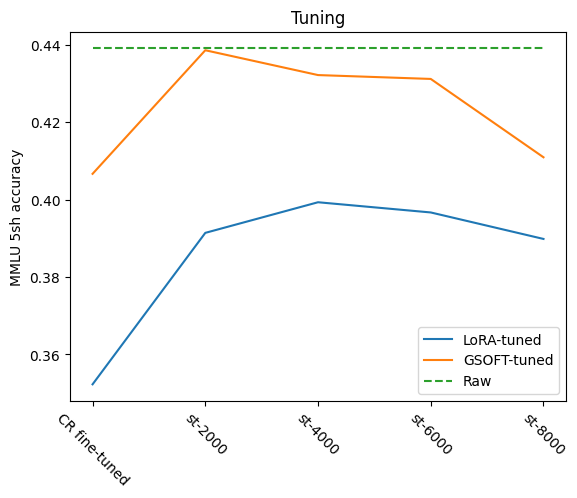

In [21]:
LoRA_scores = [total_res[total_res['run_name'] == 'LoRA_1b-CR'].accuracy[0]]
LoRA_scores += [
    total_res[total_res['run_name'] == f'LoRA_1b-code st-{st}'].accuracy[0]
    for st in range(2000, max_step+1,2000)
]

GSOFT_scores = [total_res[total_res['run_name'] == 'GSOFT_1b-CR'].accuracy[0]]
GSOFT_scores += [
    total_res[total_res['run_name'] == f'GSOFT_1b-code st-{st}'].accuracy[0]
    for st in range(2000, max_step+1,2000)
]

sns.lineplot(
    x=range(0, max_step+1, 2000),
    y=LoRA_scores,
    label='LoRA-tuned'
)

sns.lineplot(
    x=range(0, max_step+1, 2000),
    y=GSOFT_scores,
    label='GSOFT-tuned'
)

sns.lineplot(
    x=[0, max_step],
    y=[total_res[total_res['run_name'] == 'Raw 1b'].accuracy.iloc[-1]] * 2,
    linestyle='--',
    label='Raw'
)

plt.xticks(
    range(0, max_step+1,2000),
    labels=['CR fine-tuned'] + [f'st-{st}' for st in range(2000, max_step+1,2000)],
    rotation=-45
)

plt.title('Tuning')
plt.ylabel('MMLU 5sh accuracy')